In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loding the reduced dataset 
bank_reduced_df = pd.read_csv('../bank_marketing_reduced.csv')

# Data Dictionary

## Transformed Dataset

|   | Variable | Type | Pandas dtype | Description | |
|---|---|---|---|---|---|
| 1 | `age` | Numeric | `float64` | Age of the client (missing values imputed by job group median) | Original Variable |
| 2 | `job` | Categorical | `category` | Type of job (missing values imputed with mode) | Original Variable |
| 3 | `marital` | Categorical | `category` | Marital status | Original Variable |
| 4 | `education` | Categorical | `category` | Highest level of education (missing values imputed with mode) | Original Variable |
| 5 | `default` | Binary | `category` | Whether the client has credit in default (missing values imputed with mode) | Original Variable |
| 6 | `balance` | Numeric | `int64` | Average yearly balance in euros | Original Variable |
| 7 | `housing` | Binary | `category` | Whether the client has a housing loan | Original Variable |
| 8 | `loan` | Binary | `category` | Whether the client has a personal loan | Original Variable |
| 9 | `contact` | Categorical | `category` | Communication type used to contact the client (filled with "missing") | Original Variable |
| 10 | `day` | Numeric | `int64` | Last contact day of the month | Original Variable |
| 11 | `month` | Categorical | `category` | Last contact month of the year (variabled droped in reduced dataset, replaced by `month_num` ) | Original Variable |
| 12 | `duration` | Numeric | `int64` | Last contact duration in seconds | Original Variable |
| 13 | `campaign` | Numeric | `int64` | Number of contacts made during this campaign | Original Variable |
| 14 | `pdays` | Numeric | `int64` | Days since last contact from previous campaign -1 means never contacted (variable droped in reduced dataset) | Original Variable |
| 15 | `previous` | Numeric | `int64` | Number of contacts made before this campaign | Original Variable |
| 16 | `poutcome` | Categorical | `category` | Outcome of the previous marketing campaign ("unknown" filled with "missing") | Original Variable |
| 17 | `deposit` | Binary | `category` | Whether client subscribed to a term deposit | Original Variable |
| 18 | `job_was_unknown` | Binary | `int64` | 1 if `job` was originally `"unknown"` | Indicator Variable |
| 19 | `education_was_unknown` | Binary | `int64` | 1 if `education` was originally `"unknown"` | Indicator Variable |
| 20 | `contact_was_unknown` | Binary | `int64` | 1 if `contact` was originally `"unknown"` | Indicator Variables |
| 21 | `poutcome_was_unknown` | Binary | `int64` | 1 if `poutcome` was originally `"unknown"` | Indicator Variable |
| 22 | `was_previously_contacted` | Binary | `int64` | 1 if client was contacted before this campaign | Transformed Feature |
| 23 | `effective_pdays` | Numeric | `float64` | Days since last contact from previous campaign (NaN if never contacted) | Transformed Feature |
| 24 | `balance_per_contact` | Numeric | `float64` | Average yearly balance divided by number of campaign contacts | Transformed Feature |
| 25 | `duration_per_contact` | Numeric | `float64` | Last contact duration divided by number of campaign contacts | Transformed Feature |
| 26 | `has_any_loan` | Binary | `int64` | 1 if client has either a housing or personal loan, 0 for neither | Transformed Feature |
| 27 | `month_num` | Numeric | `Int64` | Month of last contact as a number (1 = Jan, 12 = Dec) | Transformed Feature |
| 28 | `quarter` | Categorical | `category` | Quarter of last contact derived from month (q1, q2, q3, q4) | Transformed Feature |
| 29 | `age_group` | Categorical | `category` | Age grouped (18-25, 26-35, 36-50, 51-65, 65+) | Transformed Feature |
| 30 | `balance_band` | Categorical | `category` | Balance grouped into quartile bands (low, medium, high, very_high) | Transformed Feature |
| 31 | `campaign_band` | Categorical | `category` | Campaign contacts grouped into frequency bands (1_contact, 2_to_3, 4_to_6, 7_plus) | Transformed Feature |
| 32 | `age_minmax` | Numeric | `float64` | Age scaled to 0–1 range | Min-Max Normalization |
| 33 | `balance_minmax` | Numeric | `float64` | Balance scaled to 0–1 range | Min-Max Normalization |
| 34 | `day_minmax` | Numeric | `float64` | Day scaled to 0–1 range | Min-Max Normalization |
| 35 | `duration_minmax` | Numeric | `float64` | Duration scaled to 0–1 range | Min-Max Normalization |
| 36 | `campaign_minmax` | Numeric | `float64` | Campaign contacts scaled to 0–1 range | Min-Max Normalization |
| 37 | `previous_minmax` | Numeric | `float64` | Previous contacts scaled to 0–1 range | Min-Max Normalization |
| 38 | `balance_per_contact_minmax` | Numeric | `float64` | Balance per contact scaled to 0–1 range | Min-Max Normalization |
| 39 | `duration_per_contact_minmax` | Numeric | `float64` | Duration per contact scaled to 0–1 range | Min-Max Normalization | 



**The reduced dataset, consisting of 37 variables, will be used for data analysis and visualization. The transformed dataset contains 39 variables, while the reduced dataset excludes `month` and `pdays`.**


In [3]:
bank_reduced_df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,...,balance_band,campaign_band,age_minmax,balance_minmax,day_minmax,duration_minmax,campaign_minmax,previous_minmax,balance_per_contact_minmax,duration_per_contact_minmax
0,58.0,management,married,tertiary,no,2143,yes,no,missing,5,...,very_high,1_contact,0.519481,0.092259,0.133333,0.053070,0.0,0.0,0.082497,0.053070
1,44.0,technician,single,secondary,no,29,yes,no,missing,5,...,low,1_contact,0.337662,0.073067,0.133333,0.030704,0.0,0.0,0.063098,0.030704
2,33.0,entrepreneur,married,secondary,no,2,yes,yes,missing,5,...,low,1_contact,0.194805,0.072822,0.133333,0.015453,0.0,0.0,0.062850,0.015453
3,47.0,blue-collar,married,secondary,no,1506,yes,no,missing,5,...,very_high,1_contact,0.376623,0.086476,0.133333,0.018707,0.0,0.0,0.076651,0.018707
4,39.0,blue-collar,single,secondary,no,1,no,no,missing,5,...,low,1_contact,0.272727,0.072812,0.133333,0.040260,0.0,0.0,0.062841,0.040260


In [4]:
bank_reduced_df.shape

(45211, 37)

In [5]:
string_variables = bank_reduced_df.select_dtypes(include = ['str']).columns.tolist()
string_variables

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'poutcome',
 'deposit',
 'quarter',
 'age_group',
 'balance_band',
 'campaign_band']

In [6]:
# changing categorical variables from string to category type
bank_reduced_df[string_variables] = bank_reduced_df[string_variables].astype('category')

# Exploratory Data Analysis

In this section, we examine the distribution of each feature and analyze its relationship with the target variable, `deposit`. This process will help us understand the data and its underlying patterns before modeling.


## Target Variable

The target variable in this analysis is `deposit`, a binary variable indicating whether a client subscribed to a term deposit following a phone marketing campaign.

In [7]:
sns.set_style('whitegrid')

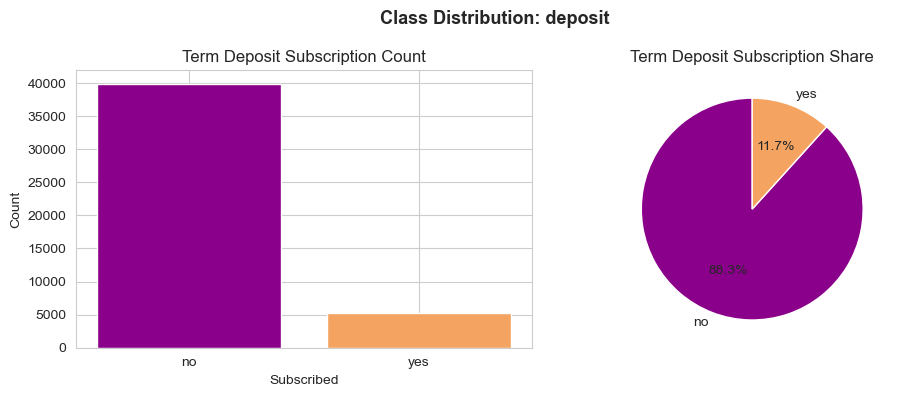

,deposit,count
0,no,39922
1,yes,5289


In [8]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

deposit_counts = bank_reduced_df['deposit'].value_counts()

axes[0].bar(deposit_counts.index, deposit_counts.values, color= ['darkmagenta', 'sandybrown'])
# axes[0].bar(deposit_counts.index, deposit_counts.values, color= ['darkviolet', 'darkorange'])
axes[0].set_title('Term Deposit Subscription Count')
axes[0].set_xlabel('Subscribed')
axes[0].set_ylabel('Count')

axes[1].pie(deposit_counts.values, labels=deposit_counts.index,
            # autopct='%1.1f%%', colors=['darkviolet', 'darkorange'], startangle=90)
            autopct='%1.1f%%', colors=['darkmagenta', 'sandybrown'], startangle=90)
axes[1].set_title('Term Deposit Subscription Share')

plt.suptitle('Class Distribution: deposit', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/target_variable_deposit_chart.png')
plt.show()

deposit_counts.reset_index()

### Findings

The target variable is `deposit`, a binary variable indicating whether a client subscribed to a term deposit following a phone marketing campaign. A term deposit is a fixed-term savings product where a customer agrees to deposit a sum of money for a set period in exchange for a guaranteed interest rate. From the bank's perspective, identifying clients who are likely to subscribe is valuable because it enables targeted marketing efforts on the most promising leads, lowering campaign costs and increasing subscriptions. 

The dataset is heavily imbalanced, with 88.3% of clients not subscribing (39,922 records) and only 11.7% subscribing (5,289 records). This kind of imbalance is common in marketing datasets, as most contacted clients will typically decline an offer, regardless of how well targeted the campaign is. However, it poses a challenge for modeling, since a model that predicts “no” for all cases might appear highly accurate but has no meaningful predictive power. Because of this, handling class imbalance is a key consideration throughout the modeling process.


## Numerical Variables
The chart below shows the distribution of all numerical variables.

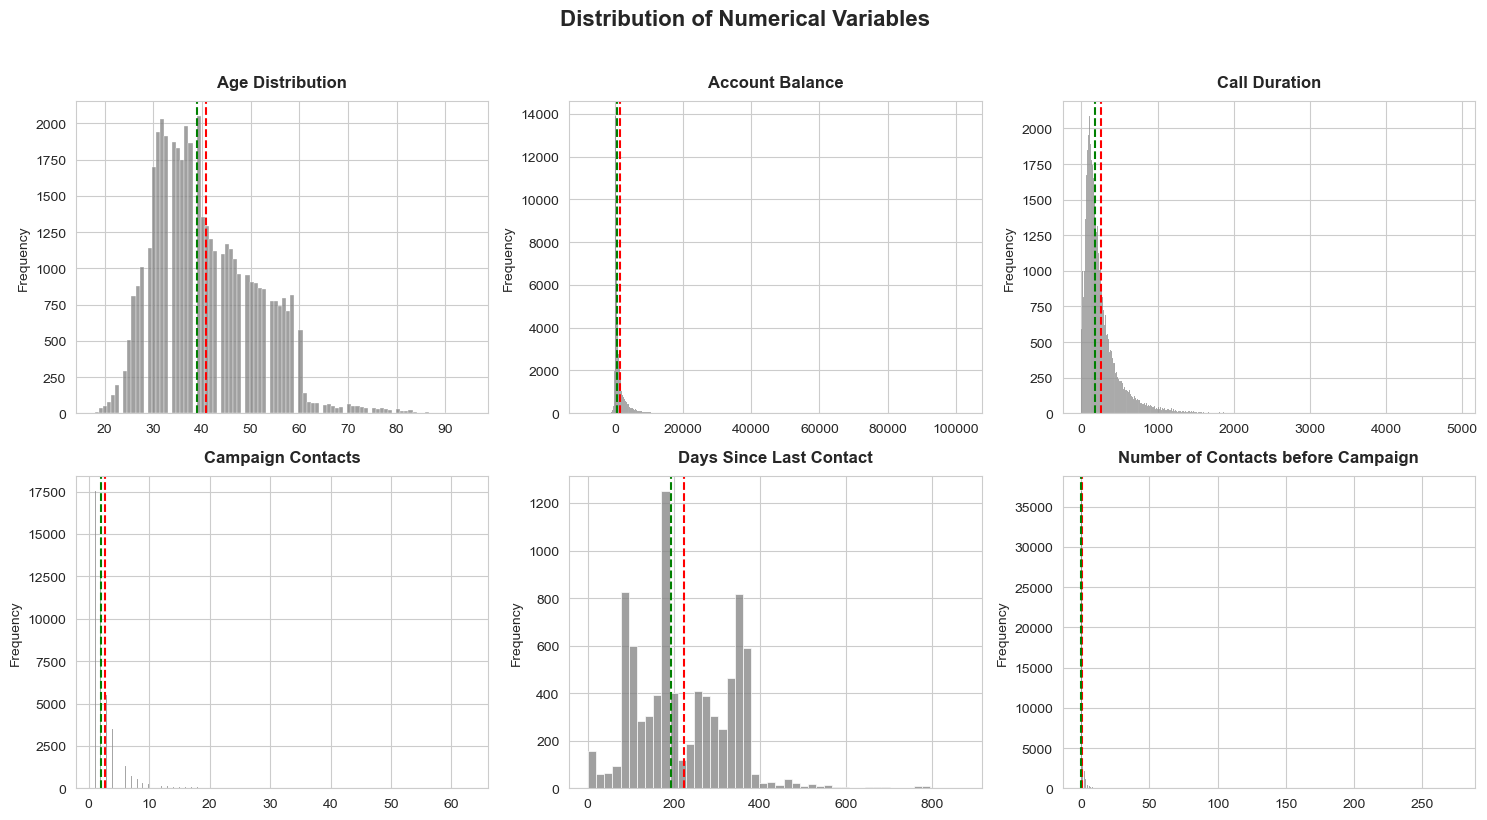

,age,balance,duration,campaign,effective_pdays,previous
mean,40.82,1362.27,258.16,2.76,224.58,0.58
median,39.00,448.00,180.00,2.00,194.00,0.00
std,10.45,3044.77,257.53,3.10,115.34,2.30
min,18.00,-8019.00,0.00,1.00,1.00,0.00
max,95.00,102127.00,4918.00,63.00,871.00,275.00
skew,0.72,8.36,3.14,4.90,0.69,41.85


In [9]:
# numerical columns to plot
numerical_cols = ['age', 'balance', 'duration', 'campaign', 'effective_pdays', 'previous']

# titles for each column
title_map = {
    'age': 'Age Distribution',
    'balance': 'Account Balance',
    'duration': 'Call Duration',
    'campaign': 'Campaign Contacts',
    'effective_pdays': 'Days Since Last Contact',
    'previous': 'Number of Contacts before Campaign'
}

# grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(data=bank_reduced_df, x=col, ax=axes[i],color='grey', kde=False)  # kde=True overlays a density curve
    # mean and median vertical lines
    axes[i].axvline(bank_reduced_df[col].mean(), color='red', linestyle='--', linewidth=1.5, label='Mean')
    axes[i].axvline(bank_reduced_df[col].median(), color='green', linestyle='--', linewidth=1.5, label='Median')
    axes[i].set_title(title_map.get(col, col.replace('_', ' ').title()), fontsize=12, fontweight='bold', pad=10)
    axes[i].set_xlabel('')  
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Numerical Variables', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/distribution_numerical_variables.png')
plt.show()

centrality = bank_reduced_df[numerical_cols].agg(['mean', 'median', 'std', 'min', 'max', 'skew']).round(2)
display(centrality)

### Findings
- `age` has as a near-normal distribution shape with a longer tail toward older ages. Most clients are between 25 and 60 years old, with a fairly close mean and median of 41 years and 39 years, respectively.
  
- In contrast, `balance` is a highly right-skewed variable, with values ranging from $-8019 \text{ €}$ to $\$ 102,127 \text{ €}$.

- Call `duration` is heavily right-skewed. Most calls are brief, with a median of 180 seconds, but some last up to 4918 seconds. Although the mean and median are similar, the distribution shows most values cluster at $0$, with a long tail of longer calls.

- Similarly, `campaign` contacts is also strongly right-skewed. Most clients were contacted only 1 to 3 times, but in extreme cases, clients were contacted up to 63 times. 

- Days since last contact, `effective_pdays` shows a likely bimodal distribution and may be better visualized by dropping all `NaNs`

- Number of contacts made before this campaign `previous` is also heavily right-skewed. The distribution shows that some clients were never contacted before, while in some extreme cases, clients were contacted up to 250 times.

## Binary Variables 
The following charts display the distribution of binary variables in the dataset, each representing a yes/no characteristic of the client or their history with the bank.

In [10]:
# Class that allows to display multiple DataFrame side by side. (Source Pandas Notebook Module 3.)
from IPython.display import display, HTML

class display(object):
    """Display HTML representation of multiple objects"""
    template = """<div style="float: left; padding: 10px;">
    <p style='font-family:"Courier New", Courier, monospace'>{0}</p>{1}
    </div>"""
    def __init__(self,*args):
        self.args = args
    def _repr_html_(self):
        return '\n'.join(self.template.format(a, eval(a)._repr_html_())
                        for a in self.args)
    def __repr__(self):
        return'\n\n'.join(a + '\n' + repr(eval(a))
                        for a in self.args)

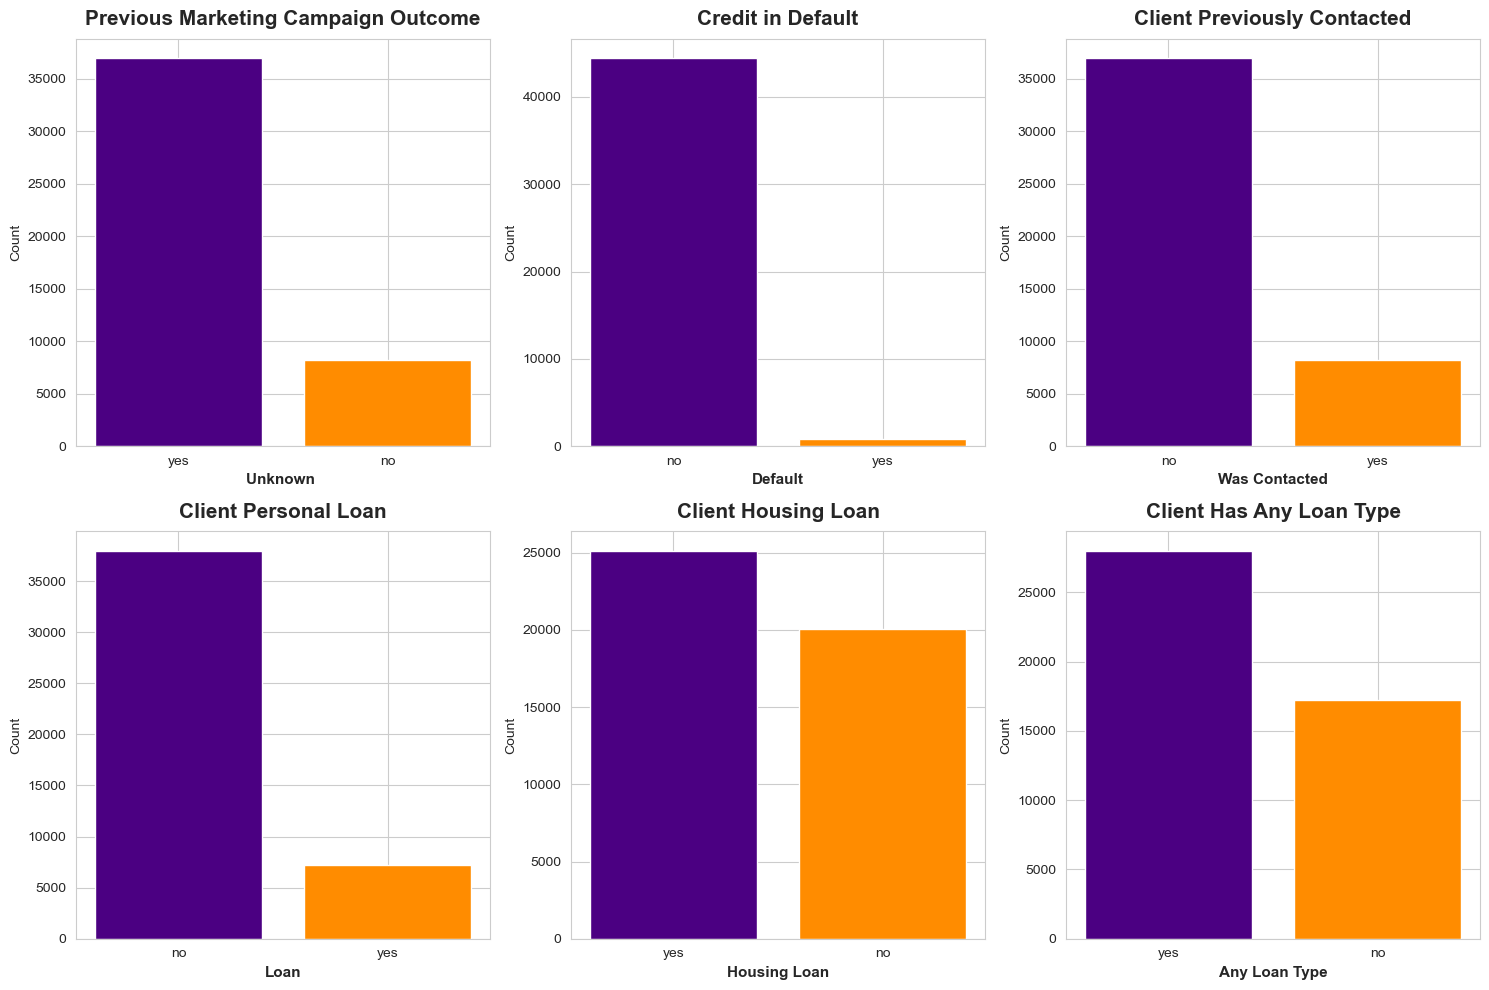

,unknown,count
0,yes,36959
1,no,8252
,default,count
0,no,44419
1,yes,792
,was contacted,count
0,no,36954
1,yes,8257
,loan,count
0,no,37967


In [11]:
# binary columns and labels
binary_cols = [
    {'col': 'poutcome_was_unknown', 'map': {0: 'no', 1: 'yes'}, 'title': 'Previous Marketing Campaign Outcome', 'xlabel': 'Unknown '},
    {'col': 'default',              'map': None,                  'title': 'Credit in Default',           'xlabel': 'Default'},
    {'col': 'was_previously_contacted', 'map': {0: 'no', 1: 'yes'}, 'title': 'Client Previously Contacted', 'xlabel': 'Was Contacted'},
    {'col': 'loan',                 'map': None,                  'title': 'Client Personal Loan',        'xlabel': 'Loan'},
    {'col': 'housing',              'map': None,                  'title': 'Client Housing Loan',         'xlabel': 'Housing Loan'},
    {'col': 'has_any_loan',         'map': {0: 'no', 1: 'yes'}, 'title': 'Client Has Any Loan Type',    'xlabel': 'Any Loan Type'},
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# store counts for display
count_dfs = {}

for i, config in enumerate(binary_cols):
    col = config['col']
    series = bank_reduced_df[col].map(config['map']) if config['map'] else bank_reduced_df[col]
    counts = series.value_counts()

    # barplots
    axes[i].bar(counts.index, counts.values, color=['indigo', 'darkorange'])
    axes[i].set_title(config['title'], fontsize=15, fontweight='bold', pad=10)
    axes[i].set_xlabel(config['xlabel'], fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Count')
    
    count_dfs[col] = counts.reset_index().set_axis([config['xlabel'].lower(), 'count'], axis=1)

poutcome_unknown = count_dfs['poutcome_was_unknown']
credit_in_default = count_dfs['default']
previous_contact = count_dfs['was_previously_contacted']
personal_loan = count_dfs['loan']
housing_loan = count_dfs['housing']
any_loan_type = count_dfs['has_any_loan']

plt.tight_layout()
plt.savefig('../images/binary_variables_barchart.png')
plt.show()

# count display
display('poutcome_unknown', 'credit_in_default', 'previous_contact', 'personal_loan', 'housing_loan', 'any_loan_type')


### Findings


- The **Previous Marketing Campaign** chart, for the `poutcome_was_unknown` variable, shows that for the majority of clients the outcome is unkown, suggesting that most clients were either not part of a prior campaign or their results were not recorded. 

- Similarly, the **Client Previously Contacted**  chart for  the `was_previously_contacted` variable, follows an identical pattern with around 37,000 clients never contacted before and about 8,000 who were. Both variables `poutcome_was_unknown` and `was_previously_contacted` seem to be closely related, so they should be further examined.

- The **Credit in Default** chart for the `default` variable shows extreme class imbalance, with only 792 clients in default compared to 44,419 who are not, which represents less than 2% of the dataset. This could indicate very low predictive value, so excluding it from the model should be considered.

- The **personal loan** chart for the `loan` variable is also imbalanced, with about 38,000 clients without a loan and 7,000 with one. However, both classes are sufficiently represented remaining useful for modeling.

- In contrast, the **housing loan** chart is the most balanced, with 25,130 clients having a housing loan while 20,081 don't, making `housing` a strong variable for the model. 

- Additionally, the **Has Any Loan Type** chart shows that approximately 62% of clients have a loan, while 38% do not. The `has_any_loan` variable is a derived feature from personal and housing loans, which could make a valuable contribution to the model.


## Nominal Variables

The following charts display the distribution of categorical variables in the dataset, including clients' previous campaign outcomes, employment types, marital status, and contact communication method.

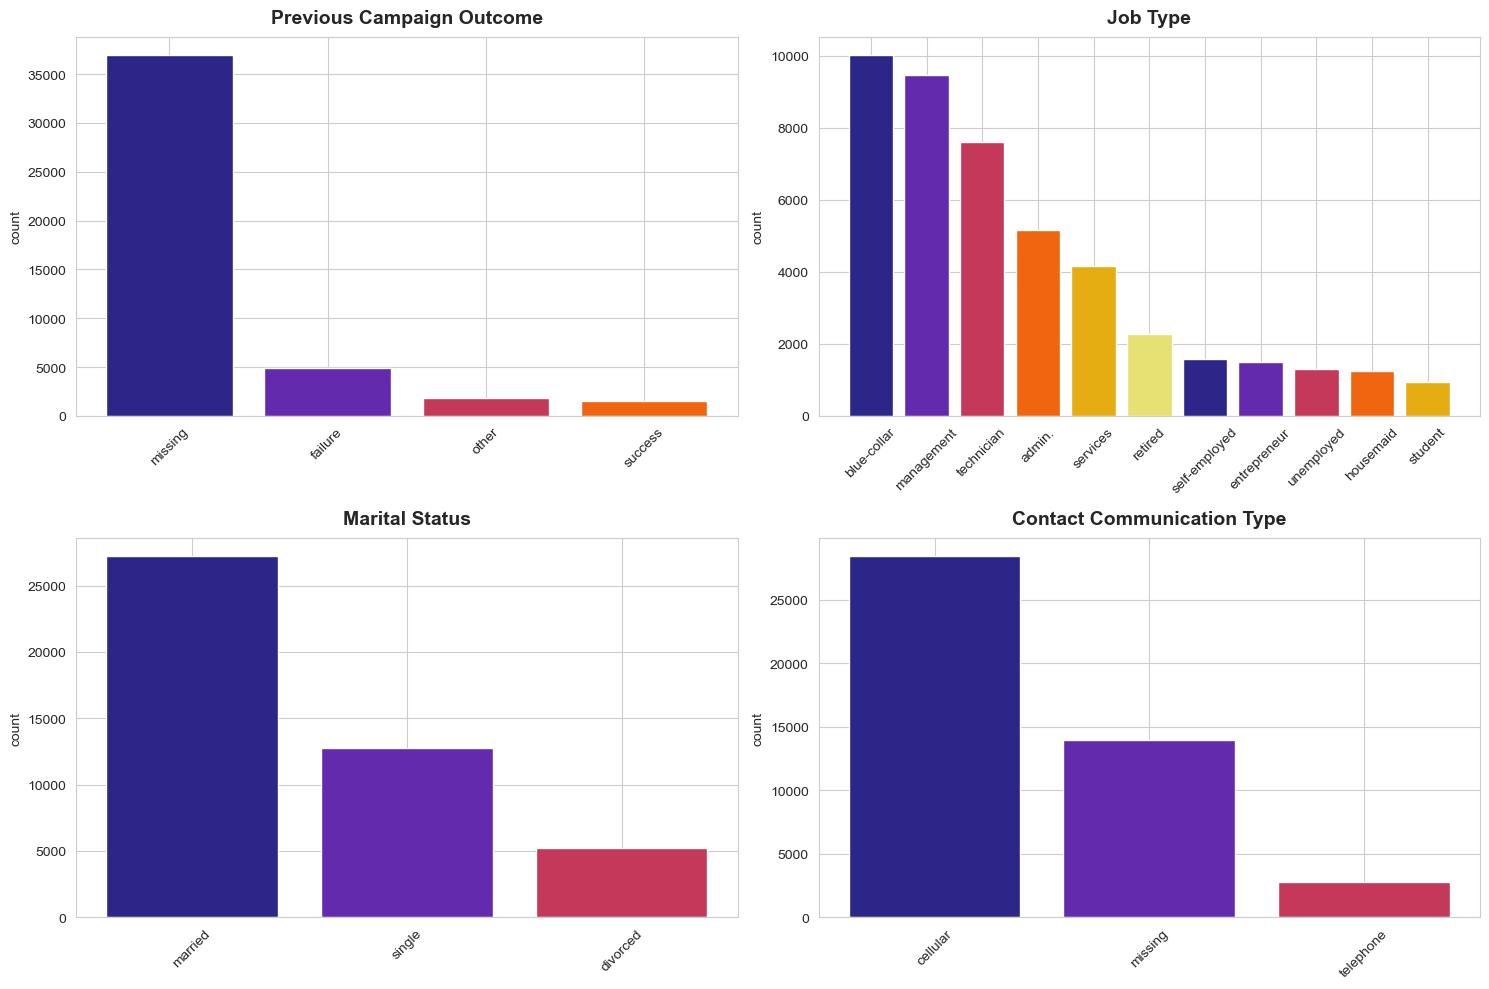

In [12]:
# Visualization of categorical variables
categorical_cols = ['poutcome', 'job', 'marital', 'contact']
title = {
    'poutcome':'Previous Campaign Outcome',
    'job':'Job Type',
    'marital':'Marital Status',
    'contact':'Contact Communication Type'
}

fig, axes = plt.subplots(2, 2,figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = bank_reduced_df[col].value_counts()
    colors = sns.color_palette(palette='CMRmap') # different color per bar   
    axes[i].bar(counts.index, counts.values, color = colors)
    axes[i].set_title(title[col], fontsize=14, fontweight='bold',pad=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('count')
    axes[i].tick_params(axis='x', rotation=45)  # rotates label

plt.tight_layout()
plt.savefig('../images/categorical_variables_barchart.png')
plt.show()

### Findings

The **Previous Campaign Outcome** chart supports the binary variable analysis. Most clients, about 36,000, have missing outcomes, with only around 5,000 failures, and roughly 1,000 successes recorded. However, the small group of clients with recorded success outcomes may still offer valuable insights, along with clients who were never contacted before.

The **Job Type** distribution is quite diverse across 10 categories, with blue-collar, management, and technician roles comprising the three largest groups, at roughly 10,000, 9,000, and 8,000 clients, respectively. Administrative and service roles follow, while categories such as retired, self-employed, entrepreneur, unemployed, housemaid, and student are relatively small. 

**Marital status** falls into three categories. Around 27,000 married, approximately 13,000 single, and about 5,000 divorced. Although married clients make up the largest group, all three categories are well represented and provide valuable insights. 

The **Contact Communication Type** shows that cellular is the most common method, with approximately 27,000 cases, while about 14,000 are missing values. Telephone is the least frequent, with around 3,000 records. The substantial amount of missing contact data stands out, and analyzing whether it is linked to the target variable could be useful, as clients without a recorded contact method may behave differently.

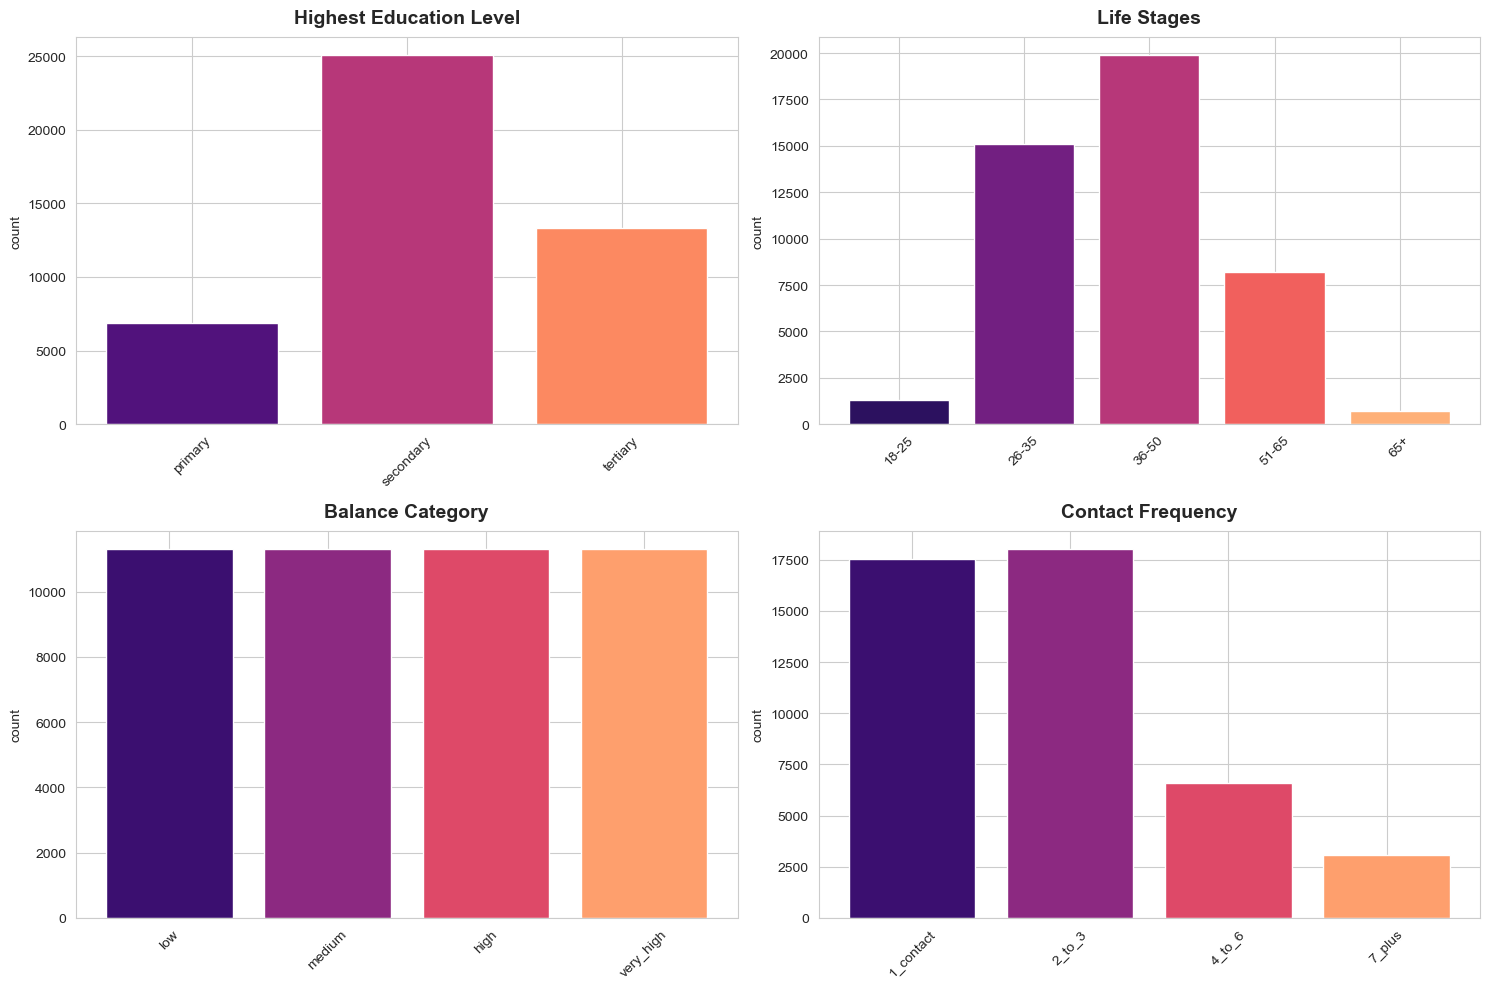

In [13]:
# visualization of ordinal columns
ordinal_order = {
    'education': ['primary', 'secondary', 'tertiary'],
    'age_group': ['18-25', '26-35', '36-50', '51-65', '65+'],
    'balance_band': ['low', 'medium', 'high', 'very_high'],
    'campaign_band': ['1_contact', '2_to_3', '4_to_6', '7_plus']
}
# ordinal variables title chart
title = {
    'education':'Highest Education Level',
    'age_group':'Life Stages',
    'balance_band':'Balance Category',
    'campaign_band':'Contact Frequency'
}

ordinal_cols = list(ordinal_order.keys())
fig, axes = plt.subplots(2, 2,figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(ordinal_cols):
    counts = bank_reduced_df[col].value_counts()
    ordered_counts = counts.reindex(ordinal_order[col])
    colors = sns.color_palette('magma', len(ordered_counts))
    axes[i].bar(ordered_counts.index, ordered_counts.values, color = colors)
    axes[i].set_title(title[col], fontsize=14, fontweight='bold',pad=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('count')
    axes[i].tick_params(axis='x', rotation=45)  # rotates label

plt.tight_layout()
plt.savefig('../images/ordinal_variables_barchart.png')
plt.show()

### Findings
**Highest Education Level** is distributed across three categories, with secondary education being the most common with about 25,000 clients, suggesting a mostly working middle class client base. Followed by higher education (tertiary), with about 13,000 clients and finally primary education with about approximately 6,500 clients.

The **Life Stages** chart, which bins clients by age group, shows that the 36-50 is the largest group, followed by 26-35 , then 51-65, and finally  the youngest 18-25 and oldest groups being the smallest. The data reflects a mostly working age base from 26 to 50.

**Contact Frequency** groups clients by how many times they were contacted during the campaign. Most clients were contacted 1 to 3 times, in a few cases 4 to 6 times, and in extreme cases more than 7 times. It would be worth exploring whether subscription rates decline as contact frequency increases.

Overall, `age_group` and `education` are well-distributed and should be included in the model.



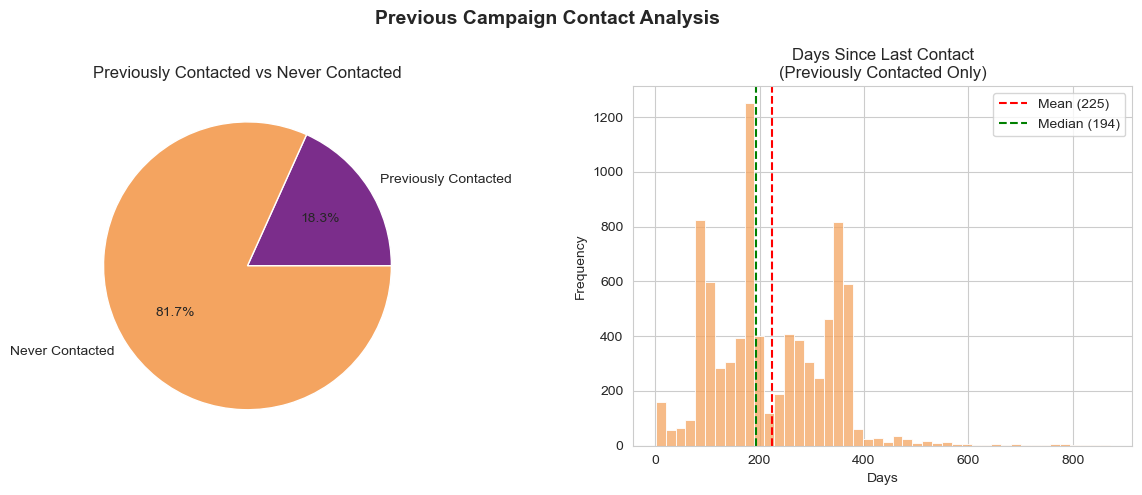

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Previous Campaign Contact Analysis', fontsize=14, fontweight='bold')

# pie chart contacted vs never contacted contrast
contacted = bank_reduced_df['effective_pdays'].notna().sum()
never_contacted = bank_reduced_df['effective_pdays'].isna().sum()
axes[0].pie([contacted, never_contacted], labels=['Previously Contacted', 'Never Contacted'],
            autopct='%1.1f%%', colors=['#7b2d8b', '#f4a460'])
axes[0].set_title('Previously Contacted vs Never Contacted')

# effective_pdays histogram no NaN
pdays_filtered = bank_reduced_df['effective_pdays'].dropna()
sns.histplot(pdays_filtered, ax=axes[1], color = 'sandybrown')
axes[1].set_title('Days Since Last Contact\n(Previously Contacted Only)')
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Frequency')
axes[1].axvline(pdays_filtered.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean ({pdays_filtered.mean():.0f})')
axes[1].axvline(pdays_filtered.median(), color='green', linestyle='--', linewidth=1.5, label=f'Median ({pdays_filtered.median():.0f})')
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/previous_campaign.png')
plt.show()

The pie chart **Previously Contacted vs Never Contacted** shows that 81.7% of customers were never contacted in a previous campaign while only 18.3% had prior contact.

The **Days Since Last Contact** barchart shows multiple peaks. Spikes are observed at about 100, 200, and 400 days, suggesting that the bank likely ran multiple campains throughout the year.  



# Bivariate and Multivariate Analysis 
## Point Plots

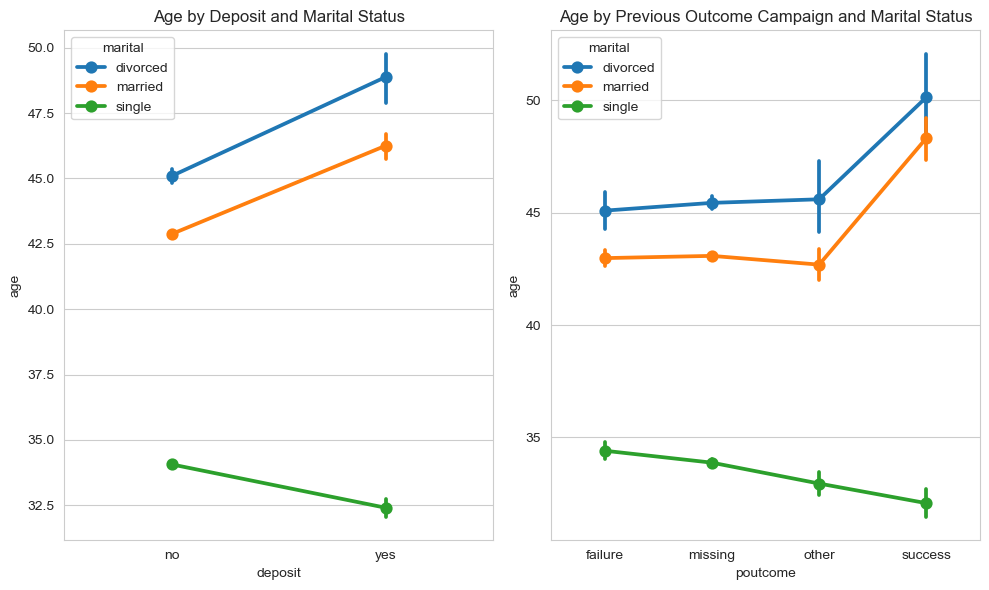

In [15]:
# age, martial status and deposit
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

sns.pointplot(data = bank_reduced_df, x = 'deposit', y = 'age', hue = 'marital', ax = axes[0])
axes[0].set_title('Age by Deposit and Marital Status')

sns.pointplot(data=bank_reduced_df, x='poutcome', y='age', hue='marital', ax=axes[1])
axes[1].set_title('Age by Previous Outcome Campaign and Marital Status')
plt.tight_layout()
plt.savefig('../images/age_marital_deposit_pplot.png')
plt.show()

### Findings
Both charts **Age by Deposit and Marital Status** and  **Age by Previous Outcome Campaign and Marital Status** show a simmilar pattern. Older individuals who are married or divorced tend to subscribe to term deposits more frequently than younger single. Similarly the previous campaign was more successful among these married or divorced older individuals. 
We can also infer from these graphs that **age and marital status** interact meaningfully, so this should be considered when modeling.


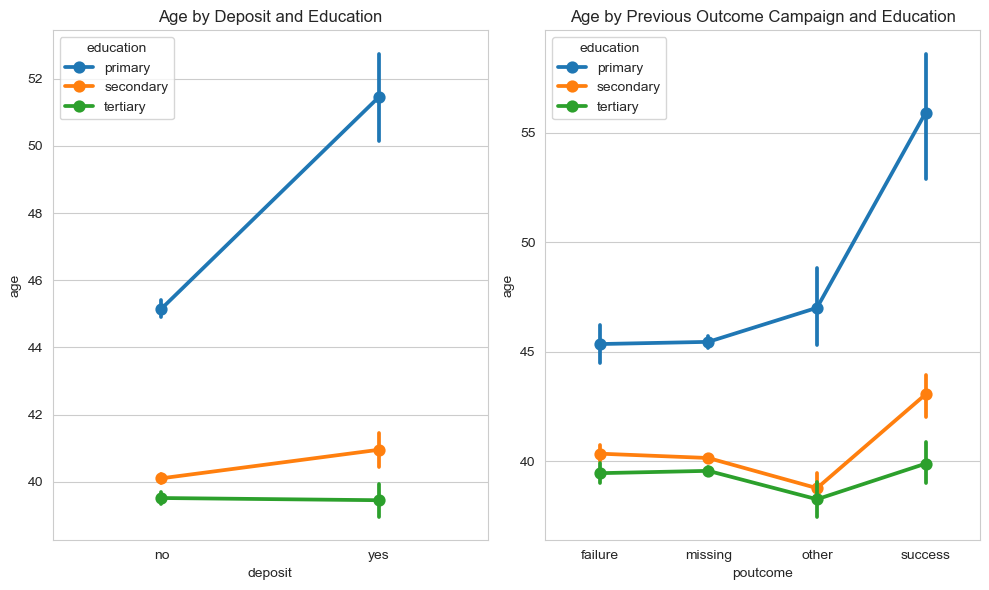

In [16]:
# age, education and deposit
fig, axes = plt.subplots(1, 2, figsize =(10,6))

sns.pointplot(data = bank_reduced_df, x ='deposit', y ='age', hue = 'education', ax=axes[0])
axes[0].set_title('Age by Deposit and Education')

sns.pointplot(data = bank_reduced_df, x ='poutcome', y ='age', hue = 'education', ax=axes[1])
axes[1].set_title('Age by Previous Outcome Campaign and Education')
plt.tight_layout()
plt.savefig('../images/age_education_deposit_pplot.png')
plt.show()

### Findings
Looking at **Age by Deposit Subscription and Education Level**, the clearest pattern appears among clients with a primary education. Those who subscribed are significantly older, averaging around 51, compared to non-subscribers, who are around 45, showing the largest age gap among all groups. In contrast, clients with secondary and tertiary education are both clustered around age 40, with only a slight increase for those who subscribed. This indicates that age has little effect on highly educated clients, but for clients with primary education, older age is strongly associated with subscription. A similar pattern is observed in **Success in Previous Campaign by Age and Education**.   

Overall, **Education Level and Age** interact in an important way, specifically for individuals with primary education. 

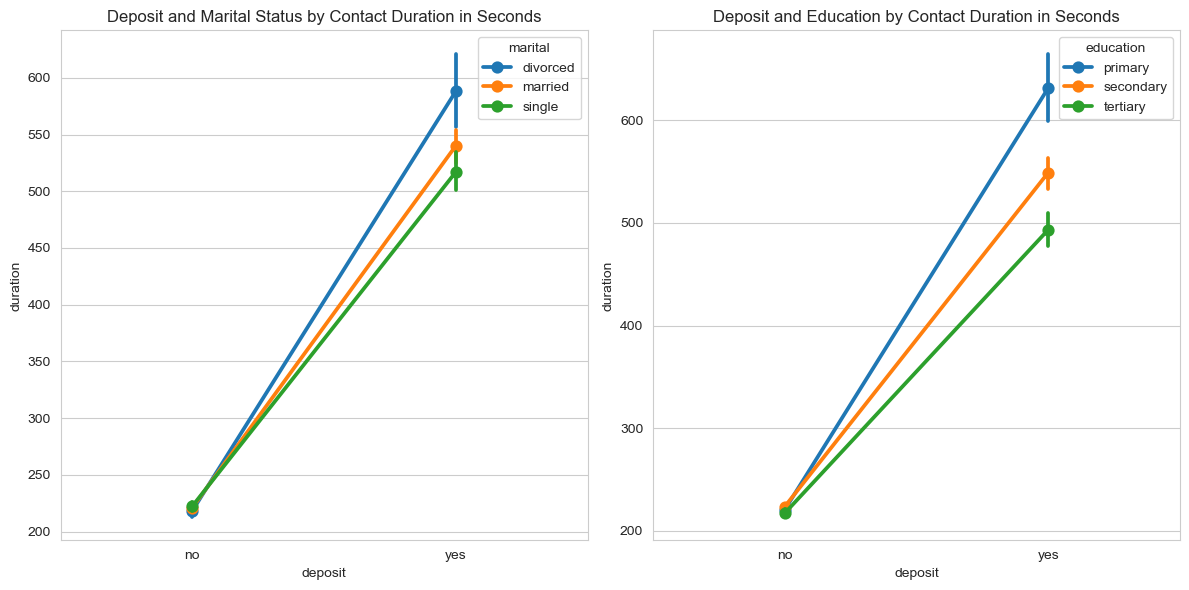

In [17]:
fig, axes = plt.subplots(1, 2, figsize =(12,6))

sns.pointplot(data = bank_reduced_df, x ='deposit', y ='duration', hue = 'marital', ax=axes[0])
axes[0].set_title('Deposit and Marital Status by Contact Duration in Seconds')

sns.pointplot(data = bank_reduced_df, x ='deposit', y ='duration', hue = 'education', ax=axes[1])
axes[1].set_title('Deposit and Education by Contact Duration in Seconds')
plt.tight_layout()
plt.savefig('../images/marital_education_duration_deposit_pplot.png')
plt.show()


### Findings
The two charts above reveal that across all **marital and education** groups, call `duration` is nearly the same for non-subscribers, with little difference between demographics. In contrast, subscribers consistently have much longer calls, around 500–620 seconds in every group.
This pattern demonstrates that longer calls are strongly linked to subscriptions but may not be a true predictive factor. This shows that calls might be longer because clients are already interested and more likely to subscribe. 

## Correlation

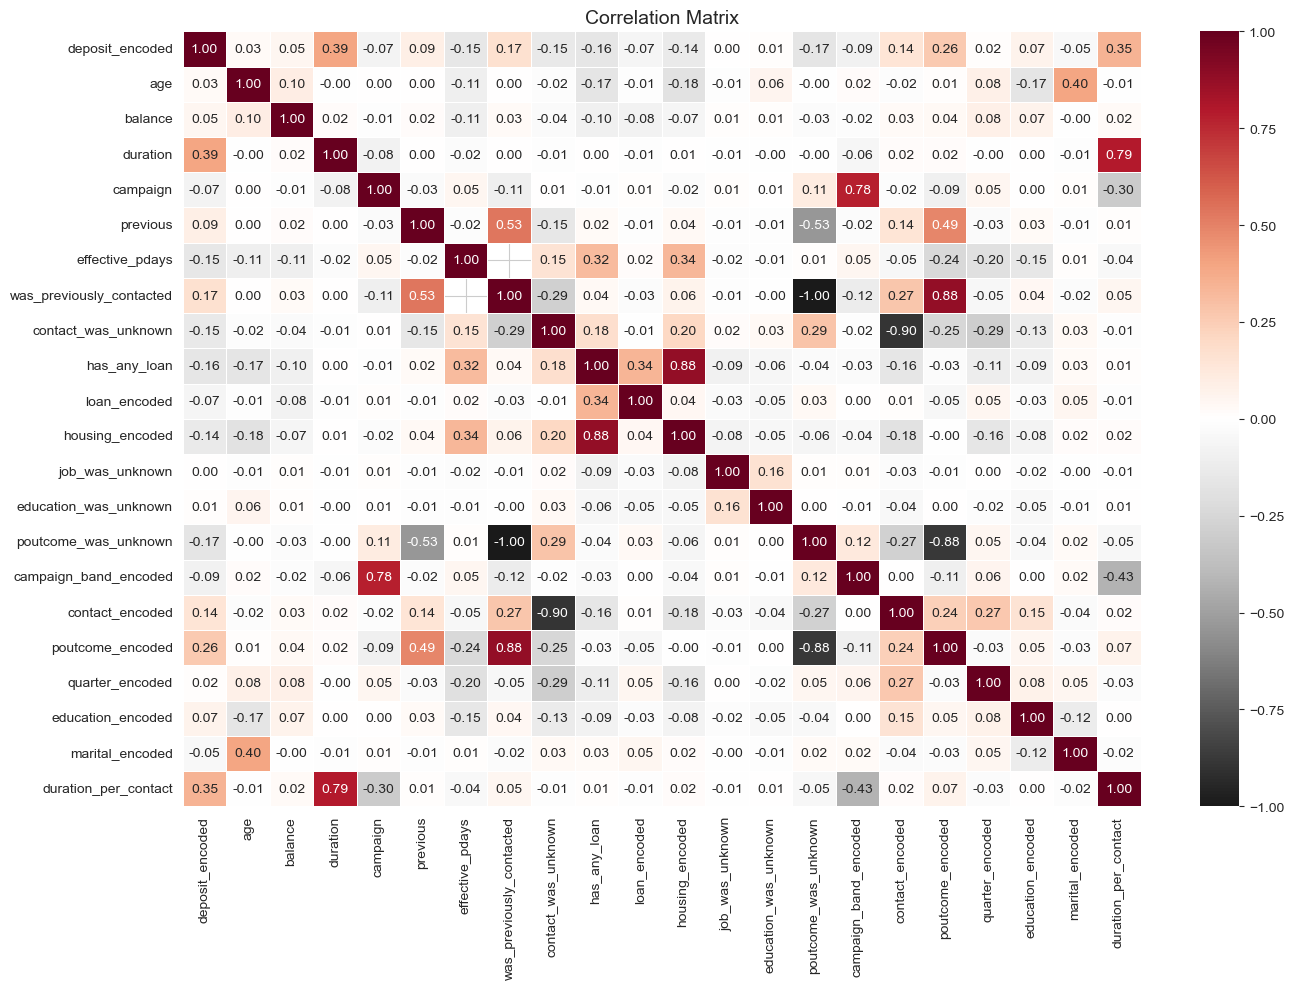

In [18]:
# Pearson Correlation Matrix

# some variables will be encoded for use in the correlation analysis 
bank_reduced_df['deposit_encoded'] = (bank_reduced_df['deposit'] == 'yes').astype(int)
bank_reduced_df['education_encoded'] = bank_reduced_df['education'].map({'primary': 0, 'secondary': 1, 'tertiary': 2})
bank_reduced_df['marital_encoded'] = bank_reduced_df['marital'].map({'single': 0, 'married': 1, 'divorced': 2})
bank_reduced_df['loan_encoded'] = bank_reduced_df['loan'].map({'no': 0, 'yes': 1})
bank_reduced_df['housing_encoded'] = bank_reduced_df['housing'].map({'no': 0, 'yes': 1})
bank_reduced_df['campaign_band_encoded'] = bank_reduced_df['campaign_band'].map({'1_contact':0, '2_to_3':1, '4_to_6':2, '7_plus':3})
bank_reduced_df['contact_encoded'] = bank_reduced_df['contact'].map({'missing': 0, 'telephone': 1, 'cellular': 2})
bank_reduced_df['poutcome_encoded'] = bank_reduced_df['poutcome'].map({'missing': 0, 'failure': 1, 'other': 2, 'success': 3})
bank_reduced_df['quarter_encoded'] = bank_reduced_df['quarter'].map({'q1': 1, 'q2': 2, 'q3': 3, 'q4': 4})

cols = ['deposit_encoded','age','balance','duration','campaign','previous','effective_pdays','was_previously_contacted',
         'contact_was_unknown','has_any_loan', 'loan_encoded','housing_encoded','job_was_unknown','education_was_unknown',
         'poutcome_was_unknown', 'campaign_band_encoded','contact_encoded','poutcome_encoded','quarter_encoded','education_encoded',
         'marital_encoded', 'duration_per_contact']


# pearson correlation
corr_matrix = bank_reduced_df[cols].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdGy_r', center=0, vmin=-1, vmax=1,linewidths=0.5)   

plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('../images/correlation_matrix.png')
plt.show()

*Note: Some variables required encoding, refer to the original variable when analyzing what to include in the model*

### Findings
The matrix displays several interesting correlations with the target variable `deposit`, as well as some expected redundancy among features that will need to be addressed before modeling. 

**Redundant predictors example:** 

`poutcome_was_unknown` and `was_previously_contacted`: -1.00

**Strong Predictors of Deposit Subscription:**

- `duration`: 0.39, appears to be the strongest predictor, but as mentioned before, this could be attributed to clients who are already interested in subscribing to a term deposit and tend to have longer calls.
-  `poutcome_encoded`: 0.26, strongest predictor of deposit subscription.
-   `contact_encoded`: 0.14
-   `effective_pdays`: -0.15


**\*Minimal Correlation with Deposit Subscription:**
- `age`
- `balance`
- `education_encoded`
- `marital_encoded`  

***\*However, these variables may still contribute to the model, as their effect depends on the selected model and whether interaction terms are included.***




## Subscription Rate Heatmaps
Heatmaps will be used to analyze how different characteristics affect subscription rates. Rather than looking at each variable separately, heatmaps will show whether certain combinations of characteristics are associated with unusually high or low subscription rates.

### Heatmap by Age, Marital Status and Education


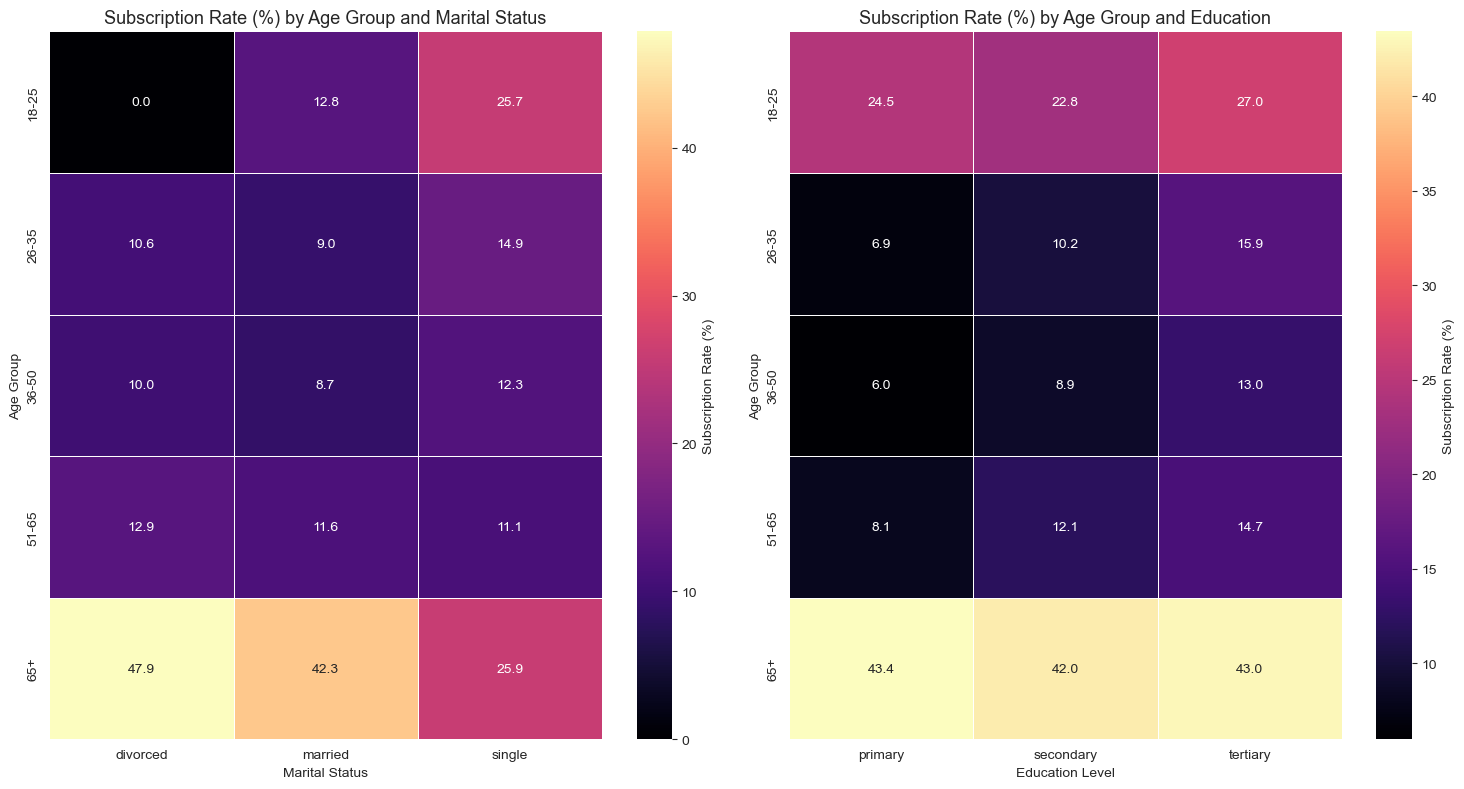

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# age group vs marital status 
pivot = (bank_reduced_df.groupby(['age_group', 'marital'])['deposit']
         .apply(lambda x: (x == 'yes').mean() * 100).reset_index())
pivot.columns = ['age_group', 'marital', 'subscription_rate']
pivot_table = pivot.pivot(index='age_group', columns='marital', values='subscription_rate')

sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='magma', linewidths=0.5,
            cbar_kws={'label': 'Subscription Rate (%)'}, ax=axes[0])
axes[0].set_title('Subscription Rate (%) by Age Group and Marital Status', fontsize=13)
axes[0].set_xlabel('Marital Status')
axes[0].set_ylabel('Age Group')

# age group vs education
pivot = (bank_reduced_df.groupby(['age_group', 'education'])['deposit']
         .apply(lambda x: (x == 'yes').mean() * 100).reset_index())
pivot.columns = ['age_group', 'education', 'subscription_rate']
pivot_table = pivot.pivot(index='age_group', columns='education', values='subscription_rate')
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='magma', linewidths=0.5,
            cbar_kws={'label': 'Subscription Rate (%)'}, ax=axes[1])
axes[1].set_title('Subscription Rate (%) by Age Group and Education', fontsize=13)
axes[1].set_xlabel('Education Level')
axes[1].set_ylabel('Age Group')

plt.tight_layout()
plt.savefig('../images/heatmap_age_marital_education.png')
plt.show()

#### Findings
- The most notable pattern in both heatmaps is the high subscription rate among clients age 65+, highlighted by the brighter colors. This trend remains consistent accross difrrent marital status and education levels, indicating that age is the main factor influencing this group.
- The middle-aged groups, specifically those aged 26-51, make up the largest portion of the dataset but have the lowest subscription rates. This may suggest limited financial flexibility, possibly due to mortgage obligations, dependents, and overall reduced disposable income.
- Aditionally, when examining education and age groups, the darker areas show that the lowest subscription rates occur among those with only primary education. This pattern could be explained by several factors. For instance, clients with lower levels of education may have lower financial literacy, making them less familiar with term deposits and their benefits. Moreover, income and savings tend to be lower among people with primary education, as they are often employed in lower-paying, blue-collar occupations.

### Heatmap by Campaign Band, Marital Status and Education

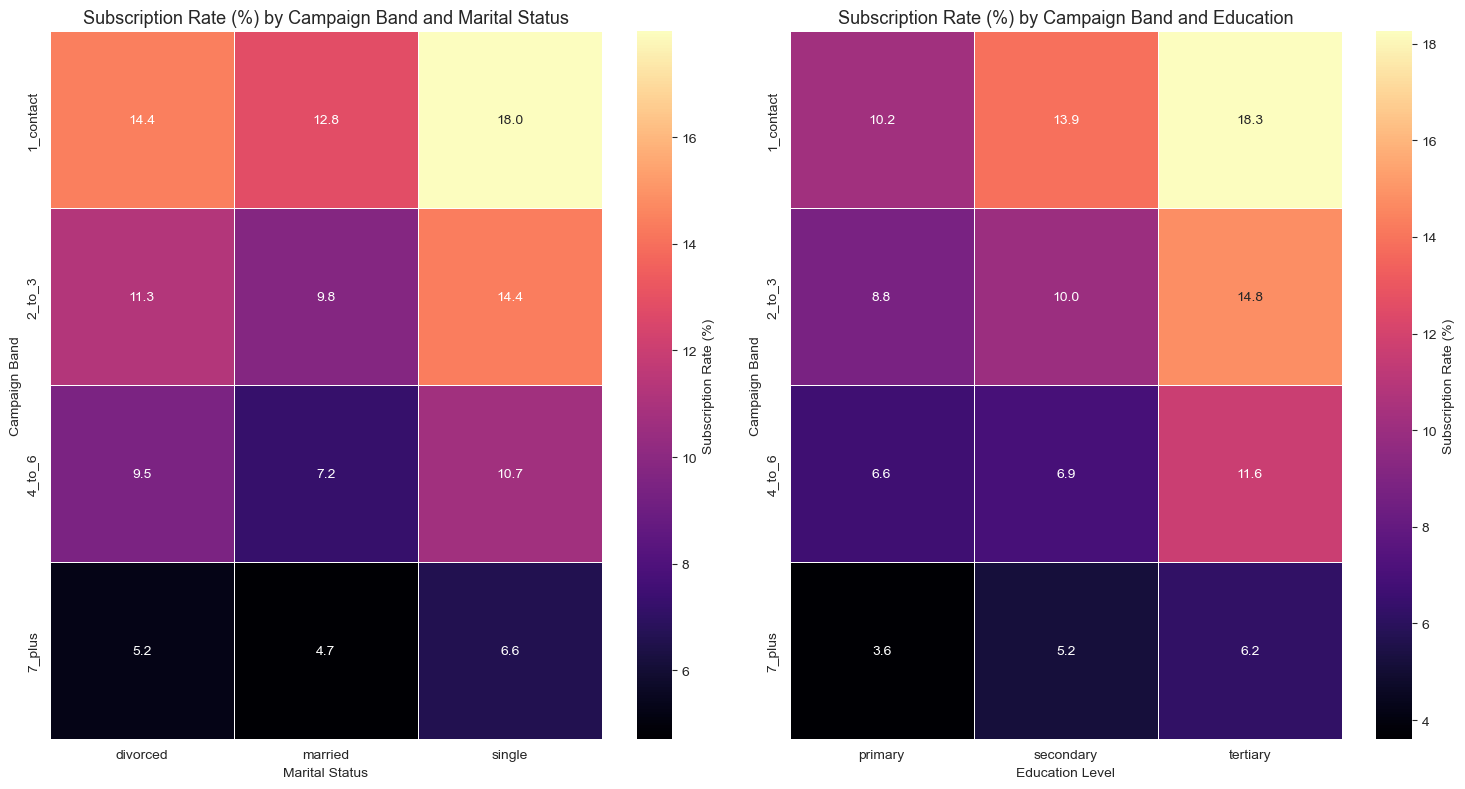

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# campaign band vs marital status
pivot = (bank_reduced_df.groupby(['campaign_band', 'marital'])['deposit']
            .apply(lambda x: (x == 'yes').mean() * 100).reset_index())
pivot.columns = ['campaign_band', 'marital', 'subscription_rate']
pivot_table = pivot.pivot(index='campaign_band', columns='marital', values='subscription_rate')

sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='magma', linewidths=0.5, 
            cbar_kws={'label': 'Subscription Rate (%)'}, ax=axes[0])
axes[0].set_title('Subscription Rate (%) by Campaign Band and Marital Status', fontsize=13)
axes[0].set_xlabel('Marital Status')
axes[0].set_ylabel('Campaign Band')

# campaign band vs education
pivot = (bank_reduced_df.groupby(['campaign_band', 'education'])['deposit']
         .apply(lambda x: (x == 'yes').mean() * 100).reset_index())
pivot.columns = ['campaign_band', 'education', 'subscription_rate']
pivot_table = pivot.pivot(index='campaign_band', columns='education', values='subscription_rate')

sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='magma', linewidths=0.5,
            cbar_kws={'label': 'Subscription Rate (%)'}, ax=axes[1])
axes[1].set_title('Subscription Rate (%) by Campaign Band and Education', fontsize=13)
axes[1].set_xlabel('Education Level')
axes[1].set_ylabel('Campaign Band')

plt.tight_layout()
plt.savefig('../images/heatmap_campaign_marital_education.png')
plt.show()

#### Findings

Both heatmaps show a consistent and clear pattern. Subscription rates decrease rapidly as the number of campaign contacts increases, regardless of marital status or education level. Clients contacted only once have the highest subscription rates across all demographic groups, while those contacted 7 or more times have the lowest. This suggests that repeated contact is either ineffective or works against success. 

Overall, `campaign` or `campaign band` appear to be a strong predictor of deposit subscription.


### Heatmap by Previous Outcome, Marital Status and Education


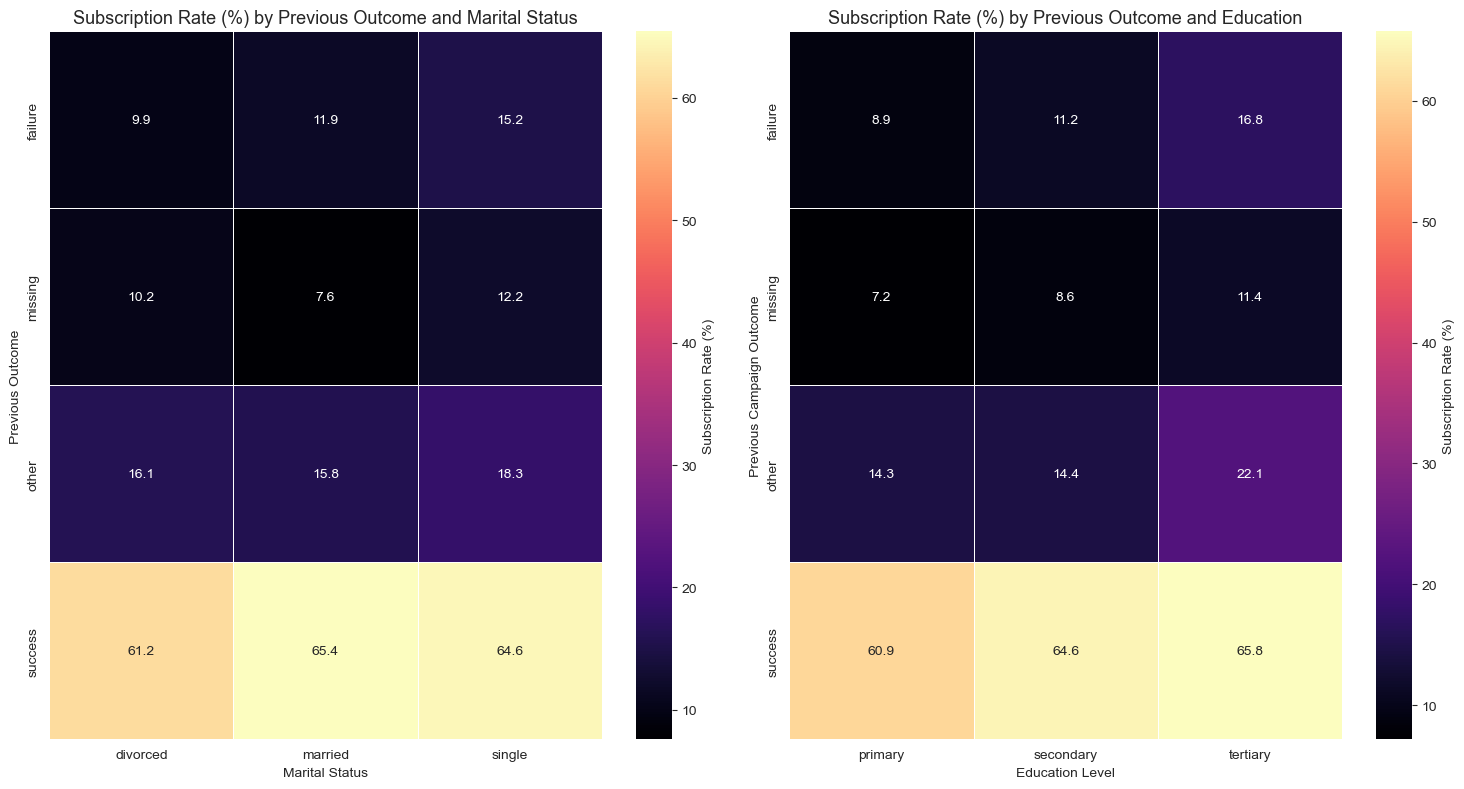

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Previous Outcome vs Education
pivot = (bank_reduced_df.groupby(['poutcome', 'marital'])['deposit']
         .apply(lambda x: (x == 'yes').mean() * 100).reset_index())
pivot.columns = ['poutcome', 'marital', 'subscription_rate']
pivot_table = pivot.pivot(index='poutcome', columns='marital', values='subscription_rate')
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='magma', linewidths=0.5,
            cbar_kws={'label': 'Subscription Rate (%)'}, ax=axes[0])
axes[0].set_title('Subscription Rate (%) by Previous Outcome and Marital Status', fontsize=13)
axes[0].set_xlabel('Marital Status')
axes[0].set_ylabel('Previous Outcome')

# Previous outcome vs Education Level
pivot = (bank_reduced_df.groupby(['poutcome', 'education'])['deposit']
         .apply(lambda x: (x == 'yes').mean() * 100).reset_index())
pivot.columns = ['poutcome', 'education', 'subscription_rate']
pivot_table = pivot.pivot(index='poutcome', columns='education', values='subscription_rate')
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='magma', linewidths=0.5,
            cbar_kws={'label': 'Subscription Rate (%)'}, ax=axes[1])
axes[1].set_title('Subscription Rate (%) by Previous Outcome and Education', fontsize=13)
axes[1].set_xlabel('Education Level')
axes[1].set_ylabel('Previous Campaign Outcome')

plt.tight_layout()
plt.savefig('../images/heatmap_poutcome_marital_education.png')
plt.show()

#### Findings

These heatmaps reveal several important insights. The success row remains consistent across both marital status and education levels. This is significant because it indicates that once a client has experienced a prior successful outcome, they are more likely to subscribe. Additionally, married clients with a prior successful campaign have a subscription rate of 65.4%, while those with higher education (tertiary) and a prior successful campaign show a rate of 65.8%. Overall, `poutcome` appears to be a strong predictor.

### Heatmap by Job, Marital Status and Education


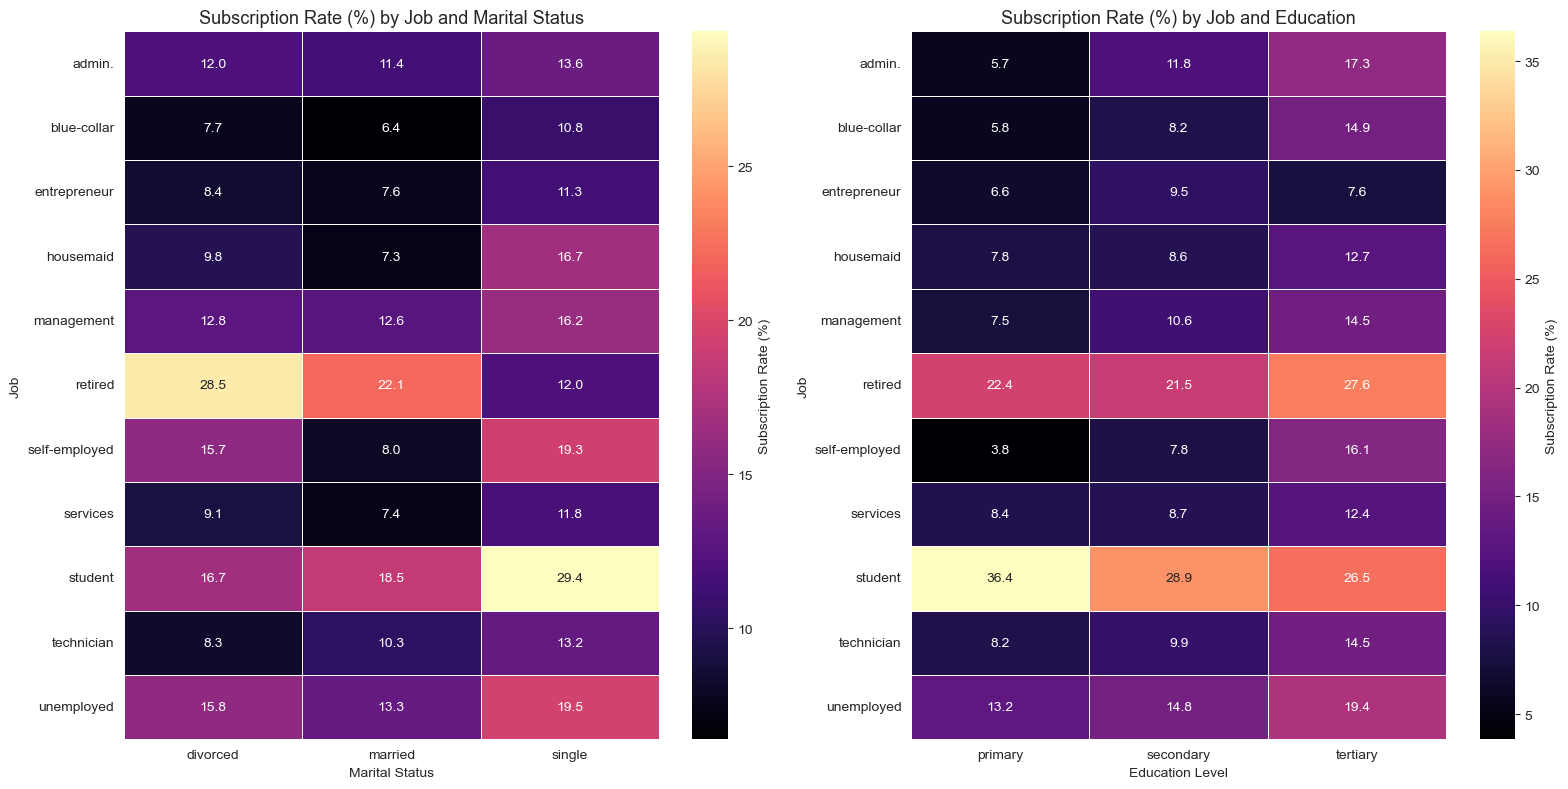

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# job vs marital status 
pivot = (bank_reduced_df.groupby(['job', 'marital'])['deposit']
         .apply(lambda x: (x == 'yes').mean() * 100).reset_index())
pivot.columns = ['job', 'marital', 'subscription_rate']
pivot_table = pivot.pivot(index='job', columns='marital', values='subscription_rate')

sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='magma', linewidths=0.5,
            cbar_kws={'label': 'Subscription Rate (%)'}, ax=axes[0])
axes[0].set_title('Subscription Rate (%) by Job and Marital Status', fontsize=13)
axes[0].set_xlabel('Marital Status')
axes[0].set_ylabel('Job')

# job vs education
pivot = (bank_reduced_df.groupby(['job', 'education'])['deposit']
         .apply(lambda x: (x == 'yes').mean() * 100).reset_index())
pivot.columns = ['job', 'education', 'subscription_rate']
pivot_table = pivot.pivot(index='job', columns='education', values='subscription_rate')
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='magma', linewidths=0.5,
            cbar_kws={'label': 'Subscription Rate (%)'}, ax=axes[1])
axes[1].set_title('Subscription Rate (%) by Job and Education', fontsize=13)
axes[1].set_xlabel('Education Level')
axes[1].set_ylabel('Job')

plt.tight_layout()
plt.savefig('../images/heatmap_job_marital_education.png')
plt.show()

### Findings
These heatmaps indicate that `job type` is highly informative feature, as subscription rates differ across various occupations. Specifically, retired clients and students are the most likely to subscribe, as both groups consistently show high subscription rates regardless of marital status or education level. This pattern had already been observed in earlier visualizations focusing on age or age groups.

### Heatmap by Job, Campaign Band and Age Group


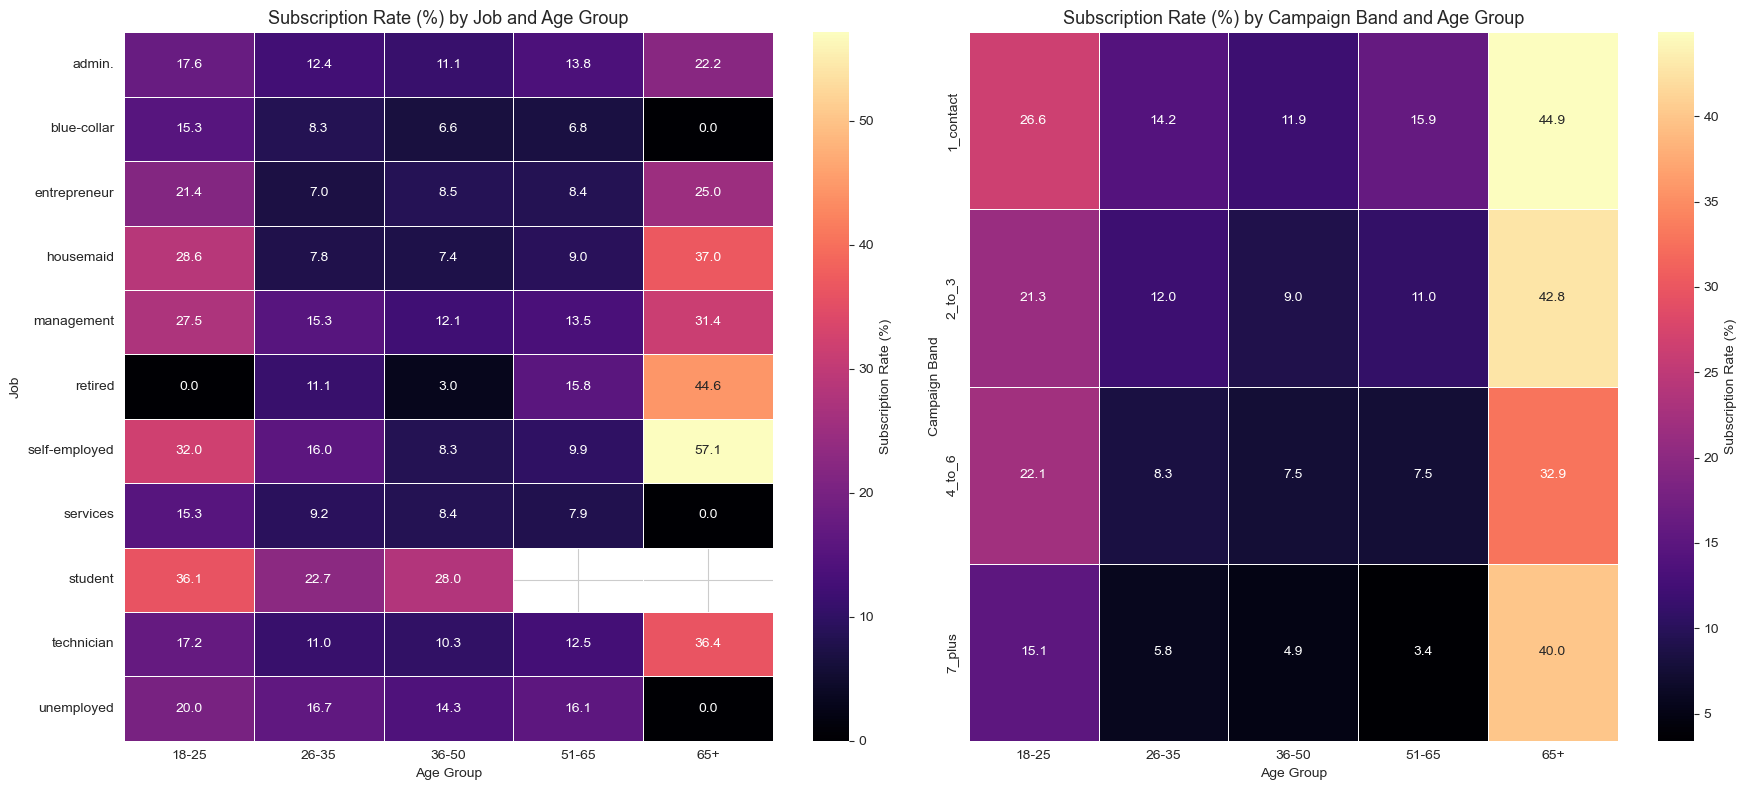

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# job vs age group
pivot = (bank_reduced_df.groupby(['job', 'age_group'])['deposit']
         .apply(lambda x: (x == 'yes').mean() * 100).reset_index())
pivot.columns = ['job', 'age_group', 'subscription_rate']
pivot_table = pivot.pivot(index='job', columns='age_group', values='subscription_rate')

sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='magma', linewidths=0.5,
            cbar_kws={'label': 'Subscription Rate (%)'}, ax=axes[0])
axes[0].set_title('Subscription Rate (%) by Job and Age Group', fontsize=13)
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Job')

# age group vs campaign band
pivot = (bank_reduced_df.groupby(['campaign_band', 'age_group'])['deposit']
         .apply(lambda x: (x == 'yes').mean() * 100).reset_index())
pivot.columns = ['campaign_band', 'age_group', 'subscription_rate']
pivot_table = pivot.pivot(index='campaign_band', columns='age_group', values='subscription_rate')
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='magma', linewidths=0.5,
            cbar_kws={'label': 'Subscription Rate (%)'}, ax=axes[1])
axes[1].set_title('Subscription Rate (%) by Campaign Band and Age Group', fontsize=13)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Campaign Band')

plt.tight_layout()
plt.savefig('../images/heatmap_job_age_campaign.png')
plt.show()

### Findings

The **Job and Age Group heatmap** show that self-employed clients aged 65+ have the highest subscription rate. This is followed by retired individuals, housemaids, management, and technicians in the same age group. Conversely, people aged 26-51 have the lowest subscription rates across all job categories, consistent with previous observations.

The **Campaign band and Age group heatmap** shows that the 65+ age group has the highest subscription rate at all contact frequency levels. Even among those contacted seven or more times, the conversion rate remains at 40.0%. Conversely, individuals aged 26-51 exhibit the lowest subscription rates across all campaign segments, with particularly low conversion rates for those with seven or more contacts.
